<a href="https://colab.research.google.com/github/c5055219/final_template/blob/main/FAKENEWSDETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FAKE NEWS DETECTION USING TRANSFORMER MODELS AND MACHINE LEANRING .

This notebook presents the implementation of a fake news detection system.the project includes data loading, exploratory data analysis (EDA), text preprocessing, feature extraction, machine learning models, transformer models and evaluation.

**1. Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import nltk

**2. Uploading the Dataset**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WELFake_Dataset.csv to WELFake_Dataset (1).csv


In [ ]:
import os
os.listdir()

['.config',
 'drive',
 'WELFake_Dataset (1).csv',
 'WELFake_Dataset.csv',
 'sample_data']

**3. Loading the Dataset**

In [ ]:
import pandas as pd
df = pd.read_csv("WELFake_Dataset.csv")
print(df.head())

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  


**4. Display the First Five Rows**

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


**5. Dataset Shape**

In [ ]:
df.shape

(72134, 4)

6. Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


**7. Missing Values**

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


**8. Duplicate Records**

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
72129,False
72130,False
72131,False
72132,False


**9. Column Names**

In [ ]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

**10. Summary Statistics**

In [ ]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [ ]:
# count the number of records in each class
df['label'].value_counts()

,count
label,
1,37106
0,35028


**11. Exploratory Data Analysis(EDA)**

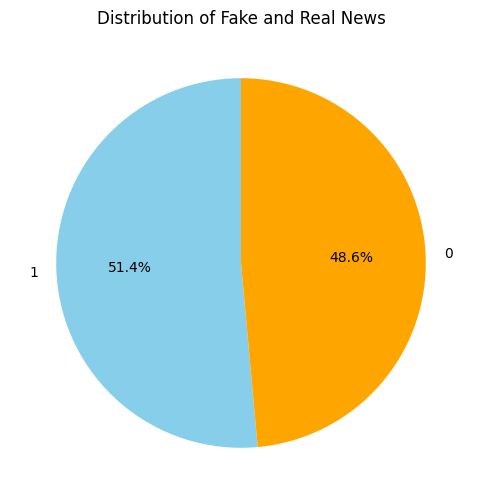

In [ ]:
# visualise the distribution of fake and real newws

plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(
    kind='pie',
    autopct= '%1.1f%%',
    colors=['skyblue','orange'],
    startangle=90
)

plt.title('Distribution of Fake and Real News')
plt.ylabel("")

plt.show()

In [ ]:
# Count the number of words in each news article
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df[['text', 'word_count']].head()

,text,word_count
0,No comment is expected from Barack Obama Membe...,871
1,Did they post their votes for Hillary already?,8
2,"Now, most of the demonstrators gathered last ...",34
3,A dozen politically active pastors came here f...,1321
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",329


In [ ]:
# Display summary statistics for word count

df['word_count'].describe()

,word_count
count,72134.000000
mean,540.551474
std,625.399281
min,0.000000
25%,227.000000
50%,398.000000
75%,667.000000
max,24234.000000


In [ ]:
# Count the number of characters in each news article

df['character_count'] = df['text'].apply(lambda x: len(str(x)))
df[['character_count']].head()

,character_count
0,5049
1,46
2,216
3,8010
4,1916


In [ ]:
# Display summary statistics for character count

df['character_count'].describe()

,character_count
count,72134.000000
mean,3268.324674
std,3732.646910
min,1.000000
25%,1377.000000
50%,2424.000000
75%,4059.000000
max,142961.000000


In [ ]:
# Count the number of characters in each news article

df['character_count'] = df['text'].apply(lambda x: len(str(x)))
df[['character_count']].head()

,character_count
0,5049
1,46
2,216
3,8010
4,1916


In [ ]:
# Display summary statistics for character count

df['character_count'].describe()

,character_count
count,72134.000000
mean,3268.324674
std,3732.646910
min,1.000000
25%,1377.000000
50%,2424.000000
75%,4059.000000
max,142961.000000


In [ ]:
# Removes the Unnamed: 0 column from the Dataframe
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

In [ ]:
# Displays all column names in the dataframe
df.columns

Index(['title', 'text', 'label', 'word_count', 'character_count'], dtype='object')

In [ ]:
# Check the number of missing values in each column

df.isnull().sum()

,0
title,558
text,39
label,0
word_count,0
character_count,0


In [ ]:
# Remove rows with missing values

df = df.dropna()

In [ ]:
# Check th enumber of duplicate records

df.duplicated().sum()

np.int64(8416)

In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

In [ ]:
# Combine the title and text into a single column

df['content'] = df['title'] + ' ' + df['text']

In [ ]:
# Combine the first five rows of the new content  column

df[['title', 'text', 'content']].head()

,title,text,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",SATAN 2: Russia unvelis an image of its terrif...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,About Time! Christian Group Sues Amazon and SP...


In [ ]:
df['clean_content'] = (
    df['content']
    .astype(str)
    .str.lower()
    .str.strip()
)

In [ ]:
# Remove punctuation from the content collumn

df['content'] = df['content'].str.translate(
    str.maketrans('', '', string.punctuation)
)

In [ ]:
# Display the first five rows of the original content column
df[['content']].head()

,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE OBAMA’S ATTORNEY GENERAL SAYS MOS...
3,Bobby Jindal raised Hindu uses story of Christ...
4,SATAN 2 Russia unvelis an image of its terrify...
5,About Time Christian Group Sues Amazon and SPL...


In [ ]:
# Create a copy of the content column for preprocessing
df['clean_content'] = df['content']

In [ ]:
# Remove extra spaces

df['clean_content'] = df['clean_content'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
# Display the first five rows of the clean_content column.
df[['clean_content']].head()

,clean_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE OBAMA’S ATTORNEY GENERAL SAYS MOS...
3,Bobby Jindal raised Hindu uses story of Christ...
4,SATAN 2 Russia unvelis an image of its terrify...
5,About Time Christian Group Sues Amazon and SPL...


**12. Tokenization**

The process of splitting a sentence or document into smaller units.

In [ ]:
# A function that splits text into words

from nltk.tokenize import word_tokenize
df['tokens'] = df['clean_content'].apply(lambda x: str(x).split())

In [ ]:
df[['clean_content', 'tokens']].head()

,clean_content,tokens
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,"[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,..."
2,UNBELIEVABLE OBAMA’S ATTORNEY GENERAL SAYS MOS...,"[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY..."
3,Bobby Jindal raised Hindu uses story of Christ...,"[Bobby, Jindal, raised, Hindu, uses, story, of..."
4,SATAN 2 Russia unvelis an image of its terrify...,"[SATAN, 2, Russia, unvelis, an, image, of, its..."
5,About Time Christian Group Sues Amazon and SPL...,"[About, Time, Christian, Group, Sues, Amazon, ..."


**13. Stop-word Removal**

Removes stop words which appear frequently in the text but usually contribute little to distinguishing between fake and real news.

In [ ]:
# download stop words
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# import stop words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords


In [ ]:
# create a stop-word set
stop_words = set(ENGLISH_STOP_WORDS)
print(list(stop_words)[:10])

['us', 'made', 'none', 'get', 'because', 'twelve', 'give', 'back', 'seeming', 'whom']


In [ ]:
# remove stop words
df['filtered_tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [ ]:
df[['tokens', 'filtered_tokens']].head()

,tokens,filtered_tokens
0,"[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,...","[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,..."
2,"[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY...","[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY..."
3,"[Bobby, Jindal, raised, Hindu, uses, story, of...","[Bobby, Jindal, raised, Hindu, uses, story, Ch..."
4,"[SATAN, 2, Russia, unvelis, an, image, of, its...","[SATAN, 2, Russia, unvelis, image, terrifying,..."
5,"[About, Time, Christian, Group, Sues, Amazon, ...","[About, Time, Christian, Group, Sues, Amazon, ..."


**14. Lemmatization**

Converting words to their base or dictionary form. without lemmatization, the machine learning model treats them as four different words.

In [ ]:
df['lemmatized_tokens'] = df['filtered_tokens']

In [ ]:
df[['filtered_tokens', 'lemmatized_tokens']].head()

,filtered_tokens,lemmatized_tokens
0,"[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,...","[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,..."
2,"[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY...","[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY..."
3,"[Bobby, Jindal, raised, Hindu, uses, story, Ch...","[Bobby, Jindal, raised, Hindu, uses, story, Ch..."
4,"[SATAN, 2, Russia, unvelis, image, terrifying,...","[SATAN, 2, Russia, unvelis, image, terrifying,..."
5,"[About, Time, Christian, Group, Sues, Amazon, ...","[About, Time, Christian, Group, Sues, Amazon, ..."


**15. Stemming**

Process of reducing a word to its root or stem by removing prefixes and suffixes.

In [ ]:
# imports the Porter stemming
from nltk.stem import PorterStemmer

In [ ]:
# creates a stemming object
stemmer = PorterStemmer()

In [ ]:
# stemming every word
df['stemmed_tokens'] = df['lemmatized_tokens'].apply(
    lambda x: [stemmer.stem(word) for word in x]
)

In [ ]:
# first five rows of stemming
df[['lemmatized_tokens', 'stemmed_tokens']].head()

,lemmatized_tokens,stemmed_tokens
0,"[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,...","[law, enforc, on, high, alert, follow, threat,..."
2,"[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY...","[unbeliev, obama’, attorney, gener, say, most,..."
3,"[Bobby, Jindal, raised, Hindu, uses, story, Ch...","[bobbi, jindal, rais, hindu, use, stori, chris..."
4,"[SATAN, 2, Russia, unvelis, image, terrifying,...","[satan, 2, russia, unv, imag, terrifi, new, ‘s..."
5,"[About, Time, Christian, Group, Sues, Amazon, ...","[about, time, christian, group, sue, amazon, s..."


16. Part-of-Speech

Uses to identify the grammatical role of each word in a sentence. Each word is assigned a tag such as noun, verb, adjective, or adverb.

In [ ]:
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
# imports the function
from nltk import pos_tag

In [ ]:
# applys pos tagging
nltk.download('averaged_perceptron_tagger_eng')
df['pos_tags'] = df['lemmatized_tokens'].apply(pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
df[['lemmatized_tokens', 'pos_tags']].head()

,lemmatized_tokens,pos_tags
0,"[LAW, ENFORCEMENT, ON, HIGH, ALERT, Following,...","[(LAW, NN), (ENFORCEMENT, NNP), (ON, NNP), (HI..."
2,"[UNBELIEVABLE, OBAMA’S, ATTORNEY, GENERAL, SAY...","[(UNBELIEVABLE, NNP), (OBAMA’S, NNP), (ATTORNE..."
3,"[Bobby, Jindal, raised, Hindu, uses, story, Ch...","[(Bobby, NNP), (Jindal, NNP), (raised, VBD), (..."
4,"[SATAN, 2, Russia, unvelis, image, terrifying,...","[(SATAN, NNP), (2, CD), (Russia, NNP), (unveli..."
5,"[About, Time, Christian, Group, Sues, Amazon, ...","[(About, IN), (Time, NNP), (Christian, NNP), (..."


**17. Text Representation**

Process of converting textual information into numerical valiues that can be processed by machine learning algorithms.

17.1 Bag of Words

Converts text into numerical values by counting how many times each word appears in a document.

In [ ]:
# import the library
from  sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Creates the Bag of Words Object
bow = CountVectorizer(max_features=5000)

In [ ]:
# Convert text into Bag of Words
X_bow = bow.fit_transform(df['clean_content'])

In [ ]:
X_bow.shape

(63121, 5000)

17.2 TF-IDF(Term Frequency-Inverse Document Frequency)

Feature extraction that converts text into numerical values by measuring how important a word is in a document compared to the entire dataset.

In [ ]:
# import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# create a TF-IDF object
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
# transform the text

X = tfidf.fit_transform(df['clean_content'])

In [ ]:
# display the shape
X.shape

(63121, 5000)

17.3 Word2Vec

Converts each word into dense numerical vector that captures the meaning and relationship between words.


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 41.7 MB/s eta 0:00:00


In [ ]:
# import Word2Vec library
from gensim.models import Word2Vec

In [ ]:
# Training th eWord2Vec model

word2vec_model = Word2Vec(
    sentences=df['lemmatized_tokens'],
    vector_size=100,
    window=5,
    min_count=1,
    sg=0
)

In [ ]:
# check the vocabulary size
len(word2vec_model.wv)

522629

In [ ]:
# display the vector for a word
word2vec_model.wv['fake']

array([-1.6730899e+00, -1.6566706e+00,  2.5030947e-01,  2.2869642e+00,
        2.7452655e+00,  3.0118227e-02, -1.7219658e-01, -3.9909836e-02,
       -2.7201051e-01,  1.0361804e+00,  1.4205540e+00, -5.1206368e-01,
       -1.7334437e-01, -1.2546381e+00,  7.2325510e-01, -2.1680791e+00,
       -1.0185834e+00, -2.0855470e+00,  3.3005376e+00,  8.2486337e-01,
        6.3679284e-01,  1.6037241e+00,  1.3638417e+00,  2.2024001e-01,
        2.7053711e+00,  2.5259655e+00,  2.0491440e+00,  2.1710949e+00,
        1.0518329e+00,  3.1515794e+00,  3.4768817e-01, -5.3859069e-03,
        7.7751791e-01,  1.9403765e+00, -3.3582768e-01, -2.2292800e+00,
       -2.8292871e+00,  1.3538778e+00,  5.1358807e-01, -3.4977016e+00,
       -2.6562978e-03, -1.8525280e-01,  3.9996925e-01,  2.1311698e+00,
       -2.1731882e-01, -1.5518667e-01, -7.0053065e-01,  1.9806718e+00,
        6.4443249e-01, -2.3290763e+00, -1.4453577e+00, -4.8247918e-01,
       -6.8099743e-01, -3.0563753e+00,  9.4461131e-01, -1.4334948e+00,
      

In [ ]:
# finds the similar words

word2vec_model.wv.most_similar('fake')

[('bogus', 0.7024186849594116),
 ('crackteam', 0.67226642370224),
 ('report’', 0.6629950404167175),
 ('false', 0.658112108707428),
 ('dangerFake', 0.6537538170814514),
 ('“fake', 0.6395629644393921),
 ('hoax', 0.6366690993309021),
 ('phony', 0.634263277053833),
 ('fabricated', 0.6297297477722168),
 ('wdfx2eu7', 0.621171236038208)]

17.4 Embeddings

Word embeddings are dense numerical vector representations of words that capture their semantic meanign and relationships.

Word embeddings allow machine learning and deep learnign models to understand the meaning of words rather than simply counting or weighting them.

They capture semantic relationships between words and improve the model's ability to understand language.

In this project, embeddings are used during the implementation of the BERT transformer model.BERT automatically contextual embeddings for each word before performing fake news classification. Therefore, a separate implementation is not requried in this stage.

**18. Feature Matrix and Target Variable**


The input data used to train mochine learning models. It contains the numerical representation of the new article generated using the TF-IDF technique.

In [ ]:
# import the TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# create the TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

In [ ]:
# convert the text into TF-IDF feature
X_tfidf = tfidf.fit_transform(df['clean_content'])

18.1 Creating the feature matrix(X)

The feature matrix(X) contains the numerical representation of the news articles generated usinf TF-IDF technique. These feature are used as the input for the machine learnign models.

In [ ]:
# create the feature matrix
X = X_tfidf

18.2 Create the Target Variable(y)

The target varible (y) contains the class labels for the news articles.



*   0 = Real News
*   1 = Fake News

The machine learning models learn the relationship between the feature matrix (X) and the target variable (y).



In [ ]:
# create the target variable
y = df['label']

In [ ]:
# check the shapes
print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (63121, 5000)
Target Variable Shape: (63121,)


**19. Train-Test Split**

The process of dividing the dataset into two separate parts:

Training Data -  used to train the machine learning model.

Testing Data - used to evaluate the performed of the training model on unseen data.

In [ ]:
# import the library
from sklearn.model_selection import train_test_split

In [ ]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# check the shapes
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (50496, 5000)
y_train (50496,)
X_test (12625, 5000)
y_test (12625,)


**20. Logistic Regression**

It is used to classify news articles as either real or fake news.

The fake news detection problem is a binary classification task with two classes:



*   0 = Real News
*   1 = Fake News



In [ ]:
# import the library
from sklearn.linear_model import LogisticRegression

In [ ]:
# create the model
lr_model = LogisticRegression(max_iter=1000)

In [ ]:
# train the model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# make predictions
lr_pred = lr_model.predict(X_test)

In [ ]:
# first 10 predictions
print(lr_pred[:10])

[1 1 0 0 1 1 1 0 0 0]


20.1 Logistic Regression Evaluation

The process of measuring how well a machine learning model performs on unseen data. After training the logistic model, its predictions are compared with the actual labels using different evaluation metrics.

In [ ]:
# import the evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# calculate accuracy
accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9443960396039603


In [ ]:
# calculate precision
precision = precision_score(y_test, lr_pred)
print("Precision:", precision)

Precision: 0.9384045181786093


In [ ]:
# claculate recall
recall = recall_score(y_test, lr_pred)
print("Recall:", recall)

Recall: 0.9377425044091711


In [ ]:
# classfication report
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      6955
           1       0.94      0.94      0.94      5670

    accuracy                           0.94     12625
   macro avg       0.94      0.94      0.94     12625
weighted avg       0.94      0.94      0.94     12625



In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, lr_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6606  349]
 [ 353 5317]]


**21. Random Forest**

It improves prediction accuracy and reduces overfitting by combining the predictions of multiple decision trees.

Random Forest is suitable for fake news detection because it can learn complex patterns in textual data and provides a strong comparison with LR and SVM.

In [ ]:
# import random forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# make predictions
rf_pred = rf_model.predict(X_test)

**Evaluates the Model**

In [ ]:
# accuracy
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.9361584158415842


In [ ]:
# precision
print("Precision:", precision_score(y_test, rf_pred))

Precision: 0.9293785310734464


In [ ]:
# recall
print("Recall:", recall_score(y_test, rf_pred))

Recall: 0.928395061728395


In [ ]:
# f1-score
print("F1-Score:", f1_score(y_test, rf_pred))

F1-Score: 0.9288865360861126


In [ ]:
# classification report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      6955
           1       0.93      0.93      0.93      5670

    accuracy                           0.94     12625
   macro avg       0.94      0.94      0.94     12625
weighted avg       0.94      0.94      0.94     12625



In [ ]:
# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Confusion Matrix:
[[6555  400]
 [ 406 5264]]


**22. Support Vector Machine (SVM)**

SVM is effective for text classification because it performs well with high dimensional data such as TF-IDF feature vector. It is capable of finding a clear separation between classes and often provides high classification accuracy.

It is a binary classification problem, SVM is an appropriate model for distingushing between real and fake news articles. It is also widely used in Natural Language Processing applications.

In [ ]:
# import SVM
from sklearn.svm import LinearSVC

In [ ]:
# create the model
svm_model = LinearSVC(random_state=42)

In [ ]:
# train the model
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [ ]:
# make predictions
svm_pred = svm_model.predict(X_test)

**Evaluate the model**

In [ ]:
# accuracy
print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.9544554455445544


In [ ]:
# precision
print("Precision:", precision_score(y_test, svm_pred))

Precision: 0.9482667605138131


In [ ]:
# recall
print("Recall:", recall_score(y_test, svm_pred))

Recall: 0.9504409171075838


In [ ]:
# f1-score
print("F1-Score:", f1_score(y_test, svm_pred))

F1-Score: 0.9493525940280102


In [ ]:
# classification report
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      6955
           1       0.95      0.95      0.95      5670

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



In [ ]:
# confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

Confusion Matrix:
[[6661  294]
 [ 281 5389]]


**23. Model Comparisons**

The three traditional machine learning models were implemented for fake news classification are Logistic Regression, Random Forest, and Support Vector Machine.

The models were trained using the same TF-IDF feature matrix and evaluated on the same testing dataset. The performance of three algorithms were compared using accuracy, precsion, recall and f1-score.

This comparison helps identify which traditional machine learning model performs best for fake news detection before comparing these models with the BERT transformer model.

In [ ]:
results = {
   "Logistic Regression":[
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ],
    "Random Forest":[
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ],
    "SVM":[
        accuracy_score(y_test, svm_pred),
        precision_score(y_test, svm_pred),
        recall_score(y_test, svm_pred),
        f1_score(y_test, svm_pred)
    ],
    "BERT": [
        0.9941386138613861,
        0.9913944502985959,
        0.995590892941623,
        0.9934882088377319
    ]
}

results_df = pd.DataFrame(results,
                          index=["Accuracy", "Precision", "Recall", "F1-Score"])
print(results_df)

           Logistic Regression  Random Forest       SVM      BERT
Accuracy              0.944396       0.936158  0.954455  0.994139
Precision             0.938405       0.929379  0.948267  0.991394
Recall                0.937743       0.928395  0.950441  0.995591
F1-Score              0.938073       0.928887  0.949353  0.993488


24. Transfromer Model (BERT)

BERT (Bidirectional Encoder Representation From Transformer)
is a transformer-based deep learning models, BERT understands the context of words by analysing both the left an dright sides of a word in a sentence. This enables it to capture semantic meaning more effectively.

BERT generates contextual word embeddings and has achieved state of the art performance in many NLP tasks, including text classification, sentiment analysis, and fake news detection.

Fake news detection requries understanding the context and meaning of text rather than simply counting words. BERT captures contextual information and is therefore expected to perform better than traditional machine learning models.

In [ ]:
# install transformer
!pip install transformers accelerate -q

In [ ]:
# import the libraries

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

import torch

**Load the BERT Tokenizer**

The BERT tokenizer converts the cleaned news articles into numerical tokens that the BERT model can understand. It applies wordpiece tokenization and prepares the text in the same format used during BERT's pre-training.

In [ ]:
# prepare the text that will be used by BERT

df['clean_content'] = (
    df['content']
    .astype(str)
    .str.lower()
    .str.strip()
)

print("BERT text column created successfully")
print(df['clean_content'].head())

BERT text column created successfully
0    law enforcement on high alert following threat...
2    unbelievable obama’s attorney general says mos...
3    bobby jindal raised hindu uses story of christ...
4    satan 2 russia unvelis an image of its terrify...
5    about time christian group sues amazon and spl...
Name: clean_content, dtype: object


In [ ]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# Test the tokenizer
sample_text = "Fake news spreads quickly"
tokens = tokenizer.tokenize(sample_text)
print(tokens)

['fake', 'news', 'spreads', 'quickly']


Prepare the Dataset for BERT

BERT cannot process raw text directly. Therefore, the cleaned news articles are converted into numerical tokens using the BERT tokenizer.

This process each news article is converted into token IDs, padding is added so all sequences have the same length, long sequence are truncated, attention masks are created to indicate which tokens are real words and which are padding. Then the processed inputs are then used to train the BERT model.

In [ ]:
from sklearn.model_selection import train_test_split

#combine title and text fro BERT
bert_text = (
    df['title'].astype(str) + " " + df['text'].astype(str)
)

X_train, X_test, y_train, y_test = train_test_split(
    bert_text,
    df['label'],
    test_size=0.2,
    random_state=42
)

print("Train Data:", X_train.shape)
print("Test Data:", X_test.shape)

Train Data: (50496,)
Test Data: (12625,)


**Create a new train_test split using text**

In [ ]:
print(type(X_train))
print(X_train.head())

<class 'pandas.core.series.Series'>
64908    Raccoons in Central Park Draw Crowds, and Warn...
37673    Merkel has no doubts UK, EU will achieve good ...
39258    Chorus grows for Clintons to shutter charitabl...
1887      John McCain Just Savaged Trump On Twitter (TW...
65562    ISIS Takes Out M1A Abrams Tank with American T...
dtype: object


**Tokenize the Training and Testing Data**

The Tokenizer converts text into numerical token IDs that can BERT understands. Here,BERT uses its own tokenizer. Padding is added so that all sequences have an equal length, while truncation ensures that long articles don't exceeed BERT.s maximum input length.

**Memory-Efficient BERT Tokenization**

The WELFake dataset contains a large number of news articles. Tokenizing the complete dataset at once can require a large amount of memory. Therefore, the text is tokenized when individual bataches are prepared for the BERT model. Dynamic padding is used so that each batch is padded only to the length required by the longest sequence in that batch.

In [ ]:
# creates a memory-efficient dataset
import torch

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length
        )

        encoding["labels"] = self.labels[idx]

        return encoding

    def __len__(self):
        return len(self.labels)

In [ ]:
# create the training and testing datasets

train_dataset = NewsDataset(
    X_train.tolist(),
    y_train.tolist(),
    tokenizer,
    max_length=256
)
test_dataset = NewsDataset(
    X_test.tolist(),
    y_test.tolist(),
    tokenizer,
    max_length=256
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))
print("Training texts:", len(train_dataset.texts))
print("Testing labels:", len(test_dataset.labels))

Training samples: 50496
Testing samples: 12625
Training texts: 50496
Testing labels: 12625


In [ ]:
# checks one article

sample = train_dataset[0]

print(sample.keys())
print("Number of tokens:", len(sample['input_ids']))
print("Label:", sample['labels'])

KeysView({'input_ids': [101, 10958, 21408, 5644, 1999, 2430, 2380, 4009, 12783, 1010, 1998, 16234, 2000, 2994, 2185, 1011, 1996, 2047, 2259, 2335, 2066, 1037, 2210, 3626, 1997, 19088, 1010, 1996, 2034, 2261, 10958, 21408, 2239, 5344, 16826, 2041, 1997, 1996, 2104, 18623, 2006, 1037, 3522, 3944, 1999, 2430, 2380, 1010, 2037, 16520, 1010, 6462, 2159, 10156, 2007, 2169, 5956, 1997, 1037, 26381, 4950, 1012, 6151, 4887, 14706, 1010, 2195, 1997, 1996, 4176, 8040, 4904, 14782, 3031, 1996, 19467, 2646, 1996, 3861, 2202, 2869, 1012, 2027, 2020, 2628, 2011, 2062, 10958, 21408, 5644, 1517, 1998, 2059, 2145, 2062, 1012, 2035, 2409, 1010, 2570, 10958, 21408, 5644, 25221, 2006, 1037, 4130, 2379, 1996, 8252, 3341, 1997, 1996, 2380, 1010, 2073, 2009, 6010, 5354, 2705, 2395, 1999, 7128, 1012, 2027, 20354, 2105, 2096, 1037, 18201, 9354, 1997, 2006, 4135, 11045, 2869, 2699, 2000, 13382, 2005, 2969, 3111, 2007, 2068, 1012, 2070, 2111, 7349, 1996, 4176, 3730, 3653, 23102, 4877, 2013, 1037, 5245, 10010, 210

In [ ]:
# Adding dynamic padding

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

**Dynamic Padding**

Dynamic padding is used to make the input sequences in each batch the same length. Instead of padding the entire dataset to the maximum length beforehand, padding is applied when each batch is created. This helps reduce unnecessary memory usage during BERT training.

In [ ]:
# dynamic padding

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"
)

print("Data collator created successfully.")

Data collator created successfully.


**Load the pre-trained BERT Model**

A pre-trained BERT model is loaded for binary text classification. The model is configured with two output labels because the WELFake dataset contains two classes: real news and fake news.

In [ ]:
# load the BERT Model

from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

print("BERT model loaded successfully.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully.


In [ ]:
import pandas as pd

df = pd.read_csv("WELFake_Dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (72134, 4)


**BERT Training Configuration**

Here, the training parameters control how the pre-trained BERT model is fine-turned on the WELFake dataset. They define the no.of training epochs, batch size and learning rate that are necessary for training.

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    report_to="none"
)

print("Training arguments set successfully.")

Training arguments set successfully.


**Create BERT Trainer**

The trainer connects the BERT model with training and testing datasets, as well as the training parameters.

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./bert_results',
    max_steps=5000,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    save_steps=1000,
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator
)

print("BERT Trainer created successfully.")

BERT Trainer created successfully.


In [ ]:
# bert training

print("Starting BERT training")

trainer.train()

print("BERT training completed successfully.")

Starting BERT training


Step,Training Loss
100,0.357605
200,0.154571
300,0.126508
400,0.089613
500,0.082435
600,0.094811
700,0.081976
800,0.058317
900,0.081938
1000,0.076611


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT training completed successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

drive_path = "/content/drive/MyDrive/BERT_Fake_News_Project"

os.makedirs(drive_path, exist_ok=True)

shutil.copytree(
        "./bert_results",
        drive_path + "/bert_results",
        dirs_exist_ok=True
)

print("BERT checkpoints saved to Google Drive.")

BERT checkpoints saved to Google Drive.


In [ ]:
final_model_path = "/content/drive/MyDrive/BERT_Fake_News_Project/final_model"

trainer.save_model(final_model_path)

print("Final BERT model and tokenizer saved to Google Drive.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final BERT model and tokenizer saved to Google Drive.


**BERT Evaluation**

The BERT model is evaluated on the unseen test dataset. Accuracy, Precision, Recall and F1-Score are used to measure the classification performance.

In [ ]:
# predictions

predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)

print("Predictions generated successfully.")


Predictions generated successfully.


In [ ]:
# calculate the metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

bert_accuracy = accuracy_score(y_test, preds)
bert_precision = precision_score(y_test, preds)
bert_recall = recall_score(y_test, preds)
bert_f1 = f1_score(y_test, preds)

print("BERT Accuracy:", bert_accuracy)
print("BERT Precision:", bert_precision)
print("BERT Recall:", bert_recall)
print("BERT F1-Score:", bert_f1)

BERT Accuracy: 0.9941386138613861
BERT Precision: 0.9913944502985599
BERT Recall: 0.9955908289241623
BERT F1-Score: 0.9934882083773319


In [ ]:
# classification report

print(classification_report(y_test, preds, target_names=["Real", "Fake"]))

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      6955
        Fake       0.99      1.00      0.99      5670

    accuracy                           0.99     12625
   macro avg       0.99      0.99      0.99     12625
weighted avg       0.99      0.99      0.99     12625



In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6906   49]
 [  25 5645]]


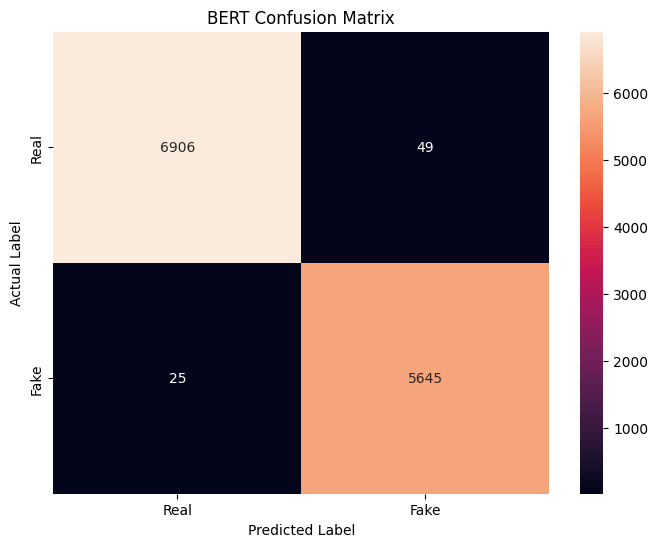

In [ ]:
# Visual Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Confusion Matrix")
plt.show()

**Attention Head Analysis**

BERT uses multi-head self attention to identify relationships between words in a news article. The BERT-base model contains 12 transformer layers, with 12 attention heads in each layer. Each attention head can learn different relationships between tokens.

The attentio weights produced by BERT are extracted and visualised to understand which tokens the model focuses on when processing a news article.

In [ ]:
# checks the BERT architecture

print("Number of layers:", model.config.num_hidden_layers)
print("Attention heads per layer:", model.config.num_attention_heads)
print("Hidden size:", model.config.hidden_size)

Number of layers: 12
Attention heads per layer: 12
Hidden size: 768


In [ ]:
# enable attetnion output
model.set_attn_implementation("eager")
model.config.output_attentions = True

In [ ]:
print("Attention implementation:", model.config._attn_implementation)
print("Output attentions:", model.config.output_attentions)

Attention implementation: eager
Output attentions: True


In [ ]:
# select one test article

sample_text = X_test.iloc[0]

print(sample_text[:1000])

 Donald Trump Responds To Mockery Over Fake Swedish Attack – Prepare To Laugh Your A** Off Last night, at a rally in Melbourne, Florida, Trump was trying to build more fear of brown people in his base of loyalists by referencing a completely imaginary terror attack in Sweden. Since then, he s received an earful from the former Prime Minister of Sweden, prompted questions from confused Swedes, and social media has been abuzz with mockery of the imaginary attack, too.One would have expected Trump to respond fairly quickly, since he s now formally joined the ranks of Kellyanne Conway and Sean Spicer when it comes to fake terror attacks, but he didn t. He waited until this afternoon to respond, and it s extremely laughable:My statement as to what s happening in Sweden was in reference to a story that was broadcast on @FoxNews concerning immigrants & Sweden.  Donald J. Trump (@realDonaldTrump) February 19, 2017Yes, sure, by all means, let s call this debacle Fox News  fault and completely i

In [ ]:
# tokenize the article
sample_inputs = tokenizer(
    sample_text,
    truncation=True,
    max_length=256,
    return_tensors="pt"
)

In [ ]:
# move it to t4
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
    )
model.to(device)
sample_inputs = {k: v.to(device) for k, v in sample_inputs.items()}

In [ ]:
model.set_attn_implementation("eager")

In [ ]:
# extract attention
model.eval()

with torch.no_grad():
    outputs = model.bert(
        **sample_inputs,
        output_attentions=True,

    )

print("Number of attention layers:", len(outputs.attentions))


Number of attention layers: 12


In [ ]:
# check the attention-head dimensions
print(outputs.attentions[0].shape)

torch.Size([1, 12, 256, 256])


In [ ]:
# get the tokens
token = tokenizer.convert_ids_to_tokens(
    sample_inputs["input_ids"][0]
)
print(tokens[:30])

['fake', 'news', 'spreads', 'quickly']


**SHAP Explainability**

SHAP (SHapley Additive exPlanations)
is used to understand why a machine learning model makes a particular prediciton.

In this project, SHAP is applied to the trained BERT model to identify which words in a news article contribute towards the prediction of real or fake news.

In [ ]:
!pip install shap -q

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

model_path = "/content/drive/MyDrive/BERT_Fake_News_Project/final_model"
tokenizer = BertTokenizer.from_pretrained(model_path)
model = BertForSequenceClassification.from_pretrained(model_path)
print("Saved BERT model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Saved BERT model loaded successfully.


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Using device:", device)

if torch.cuda.is_available():
   print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset again
df = pd.read_csv("WELFake_Dataset.csv")

# Remove the unnecessary index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Remove missing values
df = df.dropna()

# Remove duplicate records
df = df.drop_duplicates()

# Combine title and text
bert_text = (
    df['title'].astype(str) + " " + df['text'].astype(str)
)

# Recreate the same train-test split used for BERT
X_train, X_test, y_train, y_test = train_test_split(
    bert_text,
    df['label'],
    test_size=0.2,
    random_state=42
)

print("Test data recreated successfully.")
print("Test samples:", len(X_test))

Test data recreated successfully.
Test samples: 12625


In [ ]:
test_text = X_test.iloc[0]
prediction = bert_predict(test_text)
print("Prediction Probability:", prediction)

Prediction Probability: [[5.3394397e-05 9.9994659e-01]]


In [ ]:
def bert_predict(texts):

    # make sure the input is always a list of text strings
    if isinstance(texts, str):
        texts = [texts]

    else:
        texts = [str(text) for text in texts]

    # tokenize the input text
    inputs = tokenizer(
        texts,
        truncation=True,
        max_length=256,
        padding=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    # make predictions
    with torch.no_grad():
        outputs = model(**inputs)

    probabilites = torch.softmax(outputs.logits, dim=1)
    probabilites = probabilites.detach().cpu().numpy()

    return probabilites

In [ ]:
test_prediction = bert_predict([X_test.iloc[0]])
print("Prediction Probability:", test_prediction)

Prediction Probability: [[5.3394397e-05 9.9994659e-01]]


In [ ]:
import shap

masker = shap.maskers.Text(tokenizer.mask_token)
explainer = shap.Explainer(bert_predict, masker, output_names=["Real", "Fake"]
)
print("SHAP explainer createed successfully.")

SHAP explainer createed successfully.


In [ ]:
# select one test article fro SHAP explanation
shap_text = [X_test.iloc[0]]

print("Article selected for SHAP explanation.")
print(shap_text[0][:500])

Article selected for SHAP explanation.
 Donald Trump Responds To Mockery Over Fake Swedish Attack – Prepare To Laugh Your A** Off Last night, at a rally in Melbourne, Florida, Trump was trying to build more fear of brown people in his base of loyalists by referencing a completely imaginary terror attack in Sweden. Since then, he s received an earful from the former Prime Minister of Sweden, prompted questions from confused Swedes, and social media has been abuzz with mockery of the imaginary attack, too.One would have expected Trump 


In [ ]:
# generate SHAP values for the selected article

shap_values = explainer(shap_text)
print("SHAP values generated successfully.")

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.83s/it]               

SHAP values generated successfully.


In [ ]:
# display the SHAP explanation
shap.plots.text(shap_values[0])

In [ ]:
# generate BERT predictions in batches
import numpy as np
batch_size = 16
predictions = []

for start in range (0, len(X_test), batch_size):
    end = start + batch_size
    batch_texts = X_test.iloc[start:end].tolist()
    batch_predictions = bert_predict(batch_texts)
    predictions.extend(batch_predictions.argmax(axis=1))
    preds = np.array(predictions)

print("BERT predictions generated successfully.")
print("Number of predictions:", len(preds))

BERT predictions generated successfully.
Number of predictions: 12625


In [ ]:
# bert evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

bert_accuracy = accuracy_score(y_test, preds)
bert_precision = precision_score(y_test, preds)
bert_recall = recall_score(y_test, preds)
bert_f1 = f1_score(y_test, preds)

print("BERT Accuracy:", bert_accuracy)
print("BERT Precision:", bert_precision)
print("BERT Recall:", bert_recall)
print("BERT F1-Score:", bert_f1)

BERT Accuracy: 0.9941386138613861
BERT Precision: 0.9913944502985599
BERT Recall: 0.9955908289241623
BERT F1-Score: 0.9934882083773319


In [ ]:
# bert classification report
print("BERT classification Report")
print(
     classification_report(
         y_test,
         preds,
         target_names=["Real", "Fake"]
     )
 )

BERT classification Report
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      6955
        Fake       0.99      1.00      0.99      5670

    accuracy                           0.99     12625
   macro avg       0.99      0.99      0.99     12625
weighted avg       0.99      0.99      0.99     12625



In [ ]:
# confusion matrix

cm_bert = confusion_matrix(y_test, preds)
print("BERT Confusion Matrix:")
print(cm_bert)


BERT Confusion Matrix:
[[6906   49]
 [  25 5645]]
